## Exploring tsc_llm_rules results

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

In [2]:
# load data
data = []
with open('llm_rules_results.jsonl', 'r') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

In [3]:
print(df)

      dataset  classifier      llm  k  num_rules  accuracy  \
0   Chinatown  miniRocket  gpt-5.1  3          2       1.0   
1   Chinatown  miniRocket  gpt-5.1  3          2       0.3   
2   Chinatown  miniRocket  gpt-5.1  3          2       1.0   
3   Chinatown  miniRocket  gpt-5.1  3          2       0.8   
4   Chinatown  miniRocket  gpt-5.1  3          2       0.9   
..        ...         ...      ... ..        ...       ...   
75  Chinatown  miniRocket  gpt-5.1  4          5       1.0   
76  Chinatown  miniRocket  gpt-5.1  4          5       0.5   
77  Chinatown  miniRocket  gpt-5.1  4          5       0.9   
78  Chinatown  miniRocket  gpt-5.1  4          5       0.9   
79  Chinatown  miniRocket  gpt-5.1  4          5       1.0   

                                      extracted_rules  \
0   {'class_0': 'R1: The series starts at a relati...   
1   {'class_0': 'R1: The series starts relatively ...   
2   {'class_0': 'R1: The series starts at a relati...   
3   {'class_0': 'R1: In the

### Boxplot

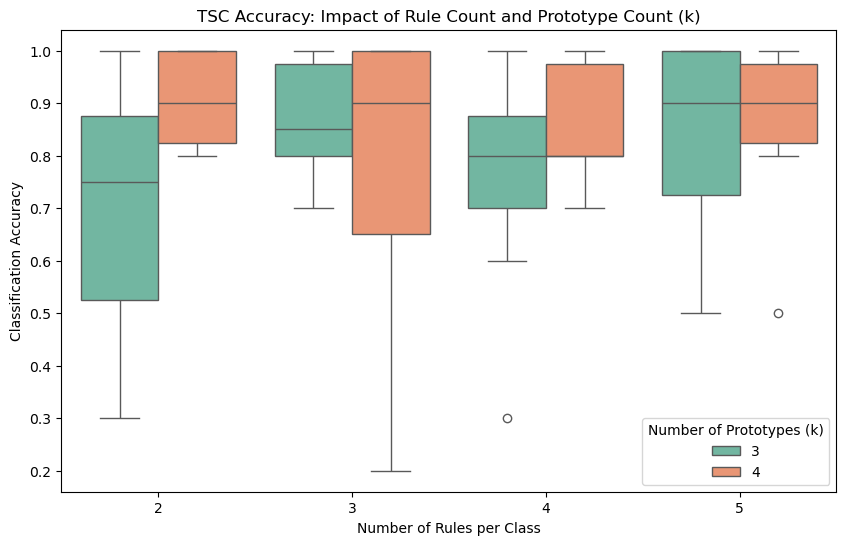

In [4]:
# accuracy vs. number of sub-rules and K (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='num_rules', y='accuracy', hue='k', palette='Set2')
plt.title('TSC Accuracy: Impact of Rule Count and Prototype Count (k)')
plt.xlabel('Number of Rules per Class')
plt.ylabel('Classification Accuracy')
plt.legend(title='Number of Prototypes (k)')
plt.savefig('llm_accuracy_boxplot.pdf', bbox_inches='tight')
plt.show()

### outlier investigation testrun 56

In [5]:
# outlier entry in k=4 and sub-rule count=3
outlier = data[55] 

print(f"OUTLIER (Line 56)")
print(f"Dataset: {outlier['dataset']} | k: {outlier['k']} | Rules: {outlier['num_rules']}")

true_labels = [inst['true_label'] for inst in outlier['instance']]
pred_labels = [inst['predicted_label'] for inst in outlier['instance']]

print("\nFull Label Sequence:")
print(f"True Labels: {true_labels}")
print(f"Pred Labels: {pred_labels}")
print(f"Total Accuracy: {outlier['accuracy']}")

print("\nThe Rules Generated for this Run")
for cls, rule_text in outlier['extracted_rules'].items():
    print(f"\n[{cls.upper()}]:\n{rule_text}")

OUTLIER (Line 56)
Dataset: Chinatown | k: 4 | Rules: 3

Full Label Sequence:
True Labels: [1, 1, 0, 1, 0, 1, 1, 1, 1, 1]
Pred Labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Total Accuracy: 0.2

The Rules Generated for this Run

[CLASS_0]:
R1: In the first 3–4 time steps, the signal has a clear **local maximum**, then steadily **decreases to a low valley** (near its minimum) around time steps 5–7.  
R2: From that valley, the signal **rises steeply** to its **global peak between time steps ~11–13**.  
R3: After the global peak, the signal **remains relatively high (plateau-like) for several steps** before **gradually decreasing** toward the end, but **does not drop as sharply** as in Class 1.



[CLASS_1]:
R1: In the first 3–4 time steps, the signal is **consistently low without an early local maximum**; it stays flat or gently declining before the rise.  
R2: From this low early region, the signal **rises steeply** to its **global peak between time steps ~13–16**, i.e., **later** than in Class 

In [ ]:
example1 = data[60]
print("\nThe Rules for another run")
for cls, rule_text in example1['extracted_rules'].items():
    print(f"\n[{cls.upper()}]:\n{rule_text}")


The Rules for another run

[CLASS_0]:
R1: The series starts at a relatively high value (around 0.2–0.35) compared with later samples.  
R2: During the first third of the time axis the series decreases to very low values near zero.  
R3: In the middle of the time axis the series rises sharply from near zero to a clear peak around 0.6–0.9.  
R4: After the peak the series stays moderately high for a while and then gradually decreases toward the end, but typically ends above its minimum.



[CLASS_1]:
R1: The series starts at a very low value (near zero), noticeably lower than the starting values of class 0.  
R2: During the first third of the time axis the series stays almost flat and very close to zero.  
R3: Around the middle the series rises sharply from this near-zero level to a peak around 0.6–0.8.  
R4: After the peak the series decreases fairly steadily toward the end, often ending near or just above the initial near-zero level.



In [ ]:
example2 = data[70]
print("\nThe Rules for another run")
for cls, rule_text in example2['extracted_rules'].items():
    print(f"\n[{cls.upper()}]:\n{rule_text}")


The Rules for another run

[CLASS_0]:
R1: In the first quarter of the series, the values start relatively high (around 0.2–0.35) and show a clear decreasing trend toward near 0.  
R2: Around the middle of the series (roughly indices 10–14), there is a single dominant peak that rises quickly from low values to around 0.6–0.9.  
R3: After that peak, the series stays at a moderately high level (roughly 0.5–0.9) for several time steps rather than dropping immediately.  
R4: In the last quarter, the values decrease gradually from that moderate/high level down to around 0.1–0.5, without an abrupt final plunge to (near) zero.  



[CLASS_1]:
R1: In the first quarter of the series, the values start low (around 0–0.1) and remain low or slightly decreasing, without an initial high value.  
R2: From early to mid indices (about 6–12), the series rises from near 0 to a high peak (about 0.6–0.8) in a steep, almost monotonic climb.  
R3: After reaching the peak, the series stays around that high lev

In [ ]:
example3 = data[40]
print("\nThe Rules for another run")
for cls, rule_text in example3['extracted_rules'].items():
    print(f"\n[{cls.upper()}]:\n{rule_text}")


The Rules for another run

[CLASS_0]:
R1: In the first third of the series, values start moderately high and show a clear downward trend from about 0.2–0.3 toward near 0 (not staying flat near zero).
R2: Around the middle of the series (roughly indices 10–15), the peak is relatively sharp and high (≈0.6–0.9) followed by a gradual decrease that does not immediately drop steeply to near zero.



[CLASS_1]:
R1: In the first third of the series, values remain very close to zero and mostly flat (near 0–0.05) without an initial moderate-high segment.
R2: After the main peak in the middle (≈0.6–0.8), the last third of the series shows a strong, almost monotonic drop from high values down to near zero.



### looking at a specific hyperparam set
- contains the outlier

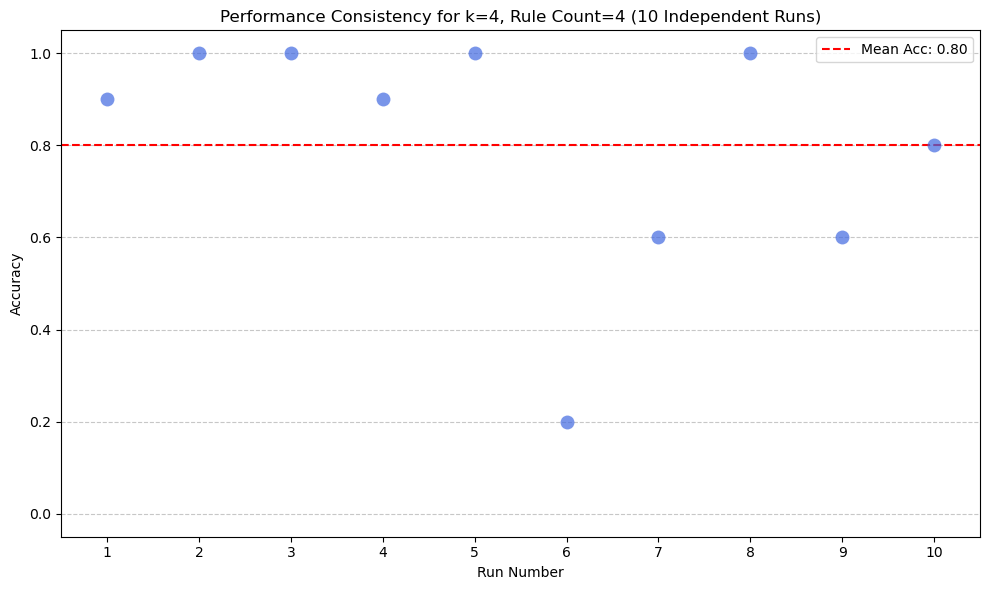

In [6]:
# filter for the specific configuration
df_specific = df[(df['k'] == 4) & (df['num_rules'] == 3)].copy()

df_specific['run_id'] = range(1, len(df_specific) + 1)


plt.figure(figsize=(10, 6))
sns.stripplot(data=df_specific, x='run_id', y='accuracy', size=10, color="royalblue", alpha=0.7)
plt.axhline(df_specific['accuracy'].mean(), color='red', linestyle='--', label=f"Mean Acc: {df_specific['accuracy'].mean():.2f}")
plt.title('Performance Consistency for k=4, Rule Count=4 (10 Independent Runs)')
plt.xlabel('Run Number')
plt.ylabel('Accuracy')
plt.ylim(-0.05, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()


plt.tight_layout()
plt.savefig('llm_k4_rules3_consistency.pdf')
plt.show()

### tables

In [7]:
accuracy_table = df.pivot_table(
    index='k', 
    columns='num_rules', 
    values='accuracy', 
    aggfunc='mean'
)

print("Average Accuracy: k (rows) vs. Number of Rules (columns)")
display(accuracy_table.style.background_gradient(cmap='RdYlGn', axis=None).format("{:.2%}"))

Average Accuracy: k (rows) vs. Number of Rules (columns)


num_rules,2,3,4,5
k,,,,
3,70.00%,87.00%,76.00%,84.00%
4,91.00%,80.00%,85.00%,87.00%


In [8]:
# Aggregate accuracy by number of rules
rules_summary = df.groupby('num_rules')['accuracy'].agg(['mean', 'count']).reset_index()

# Rename columns for clarity
rules_summary.columns = ['Sub-rule Count', 'Mean Accuracy', 'N (Runs)']

print("Summary: Performance by Rule Complexity")
display(rules_summary.style.format({'Mean Accuracy': '{:.2%}'}))

Summary: Performance by Rule Complexity


,Sub-rule Count,Mean Accuracy,N (Runs)
0,2,80.50%,20
1,3,83.50%,20
2,4,80.50%,20
3,5,85.50%,20


In [9]:
# Aggregate accuracy by k
k_summary = df.groupby('k')['accuracy'].agg(['mean', 'count']).reset_index()

# Rename columns for clarity
k_summary.columns = ['k (Prototypes)', 'Mean Accuracy', 'N (Runs)']

print("Summary: Performance by Prototype Count")
display(k_summary.style.format({'Mean Accuracy': '{:.2%}'}))

Summary: Performance by Prototype Count


,k (Prototypes),Mean Accuracy,N (Runs)
0,3,79.25%,40
1,4,85.75%,40
